<a href="https://colab.research.google.com/github/Jessicaamc/Projetos_ADA/blob/main/Fundamentos_de_Marchine_Learning_Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="#2E86C1"><h2>Projeto Final ADA Fundamentos de Machine Learning</h2></font>


**Nome:** Jéssica Alves de Melo Caetano

**Modelo:** Regressão Linear



**Dataset:** [Global Climate Energy 2020-2024](https://raw.githubusercontent.com/Jessicaamc/Projetos_ADA/refs/heads/main/global_climate_energy_2020_2024%20(1).csv)



##DESCRIÇÃO DO PROBLEMA

Este projeto tem como objetivo desenvolver e avaliar um modelo de regressão linear para estimar o consumo de energia (energy_consumption) com base em variáveis ambientais, econômicas e demográficas presentes no conjunto de dados, como temperatura média, umidade, emissão de CO₂, participação de energias renováveis, população urbana, atividade industrial e preço da energia. A avaliação do modelo permitirá analisar o potencial preditivo dessas variáveis e verificar sua capacidade de explicar o comportamento do consumo de energia, contribuindo para o entendimento das relações existentes entre os fatores analisados.


###Seleção de Dados
O dataset utilizado neste projeto foi obtido por meio da plataforma Kaggle, sendo denominado Global_Climate_Energy_2020_2024. Este conjunto de dados fornece cinco anos (2020–2024) de dados sintéticos diários combinando indicadores climáticos globais e estatísticas de consumo de energia para 50 países em todos os continentes. O conjunto de dados simula padrões reais de clima e energia usando tendências sazonais dinâmicas, flutuações da atividade industrial e diferenças regionais.
Todos os valores são gerados programaticamente e suavizados para se assemelhar a dados realistas em nível de país.



###Atributos do Dataset
O dataset possui 10 colunas, sendo:

**Data**: Data diária do registro (YYY-MM-DD)

**País**: Nome do país

**avg_temperature**: Temperatura média diária em Celsius (°C)

**Umidade**: Umidade relativa média (%)

**co2_emission**: Estimadas emissões diárias de CO₂ (toneladas/dia)

**energy_consumption**: Consumo total diário de eletricidade (MWh/dia)

**renewable_share**: Porcentagem de energia proveniente de fontes renováveis (%)

**urban_population**: Porcentagem da população total vivendo em áreas urbanas (%)

**industrial_activity_index**: Índice escalonado (0–100) indicando o nível de produção industrial

**energy_price**: Preço médio da eletricidade em €/MWh


##IMPORTAÇÃO DAS BIBLIOTECAS E CARREGAMENTO DO DATASET






In [ ]:
#importando as bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#carregando o Dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ADA PROJETO/global_climate_energy_2020_2024.csv')

Mounted at /content/drive


In [ ]:
#Exibindo primeiras linhas do Dataset
df.head()

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


##ANALISE EXPLORATÓRIA DE DADOS


In [ ]:
#Verificando tamanho do dataset
df.shape

(36540, 10)

O dataset global_climate_energy_2020_2024 contém 36.540 linhas e possui 10 atributos.

In [ ]:
# Verificando informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36540 entries, 0 to 36539
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       36540 non-null  object 
 1   country                    36540 non-null  object 
 2   avg_temperature            36540 non-null  float64
 3   humidity                   36540 non-null  float64
 4   co2_emission               36540 non-null  float64
 5   energy_consumption         36540 non-null  float64
 6   renewable_share            36540 non-null  float64
 7   urban_population           36540 non-null  float64
 8   industrial_activity_index  36540 non-null  float64
 9   energy_price               36540 non-null  float64
dtypes: float64(8), object(2)
memory usage: 2.8+ MB


In [ ]:
# Estatísticas Descritivas
df.describe()

,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
count,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000,36540.000000
mean,13.580868,59.971469,445.820452,7295.904857,15.944080,74.982156,70.173094,115.279848
std,10.077249,17.303103,234.360906,3693.928504,5.334804,8.645400,17.334816,49.178361
min,-9.600000,30.000000,50.150000,1001.890000,5.000000,60.000000,40.000000,30.000000
25%,5.630000,45.010000,248.675000,4184.177500,12.020000,67.470000,55.300000,72.420000
50%,13.790000,59.990000,422.655000,6921.620000,15.715000,75.030000,70.055000,115.240000
75%,20.840000,74.970000,628.422500,10175.110000,19.840000,82.502500,85.260000,158.270000
max,38.710000,90.000000,999.850000,15998.050000,30.870000,90.000000,100.000000,200.000000


In [ ]:
# Resumo estatístico completo das variáveis numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

resumo = pd.DataFrame({
    'Mínimo':     df[num_cols].min(),
    'Máximo':     df[num_cols].max(),
    'Média':      df[num_cols].mean().round(2),
    'Mediana':    df[num_cols].median(),
    'Moda':       df[num_cols].mode().iloc[0],
    'Desvio-padrão': df[num_cols].std().round(2),
})
resumo

,Mínimo,Máximo,Média,Mediana,Moda,Desvio-padrão
avg_temperature,-9.60,38.71,13.58,13.790,16.46,10.08
humidity,30.00,90.00,59.97,59.990,66.25,17.30
co2_emission,50.15,999.85,445.82,422.655,145.33,234.36
energy_consumption,1001.89,15998.05,7295.90,6921.620,7257.01,3693.93
renewable_share,5.00,30.87,15.94,15.715,13.93,5.33
urban_population,60.00,90.00,74.98,75.030,82.55,8.65
industrial_activity_index,40.00,100.00,70.17,70.055,45.25,17.33
energy_price,30.00,200.00,115.28,115.240,48.66,49.18


Matriz de Correlação:


,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
avg_temperature,1.000000,0.004675,0.004647,-0.006845,-0.003454,0.002122,-0.000390,0.000455
humidity,0.004675,1.000000,0.000547,0.003214,0.008300,0.000946,-0.008132,-0.000133
co2_emission,0.004647,0.000547,1.000000,0.171758,-0.001837,-0.002710,0.002069,0.004401
energy_consumption,-0.006845,0.003214,0.171758,1.000000,-0.002070,0.005503,-0.008340,-0.007559
renewable_share,-0.003454,0.008300,-0.001837,-0.002070,1.000000,-0.006074,-0.004065,0.001826
urban_population,0.002122,0.000946,-0.002710,0.005503,-0.006074,1.000000,0.007666,-0.001499
industrial_activity_index,-0.000390,-0.008132,0.002069,-0.008340,-0.004065,0.007666,1.000000,0.010577
energy_price,0.000455,-0.000133,0.004401,-0.007559,0.001826,-0.001499,0.010577,1.000000


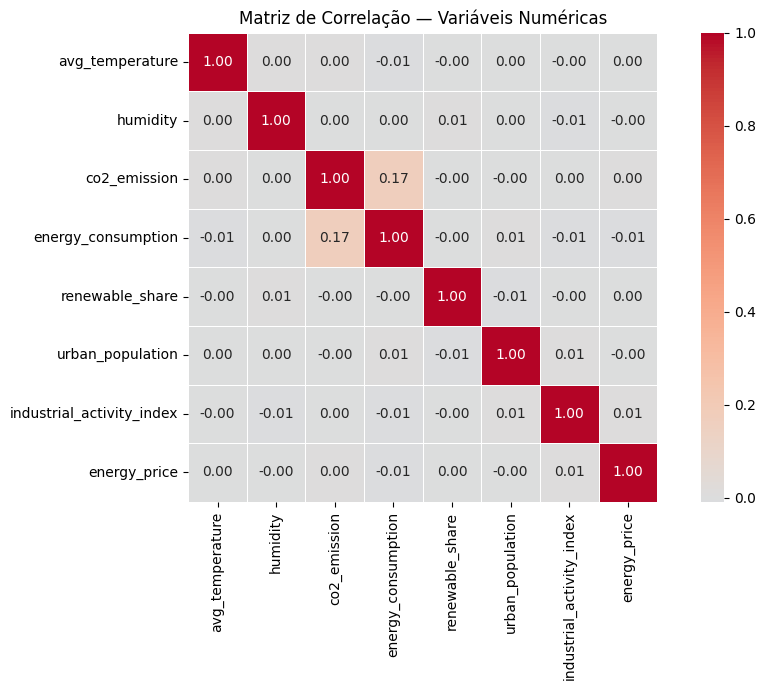

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = df[num_cols].corr()

# Display the correlation matrix
print("Matriz de Correlação:")
display(corr_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Matriz de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.show()

 A análise da matriz de correlação mostrou que as variáveis independentes apresentam baixa relação linear com a variável alvo (energy_consumption). Dessa forma, espera-se que o modelo de Regressão Linear tenha capacidade limitada de explicar a variação do consumo de energia, uma vez que esse algoritmo pressupõe relações lineares entre as variáveis.

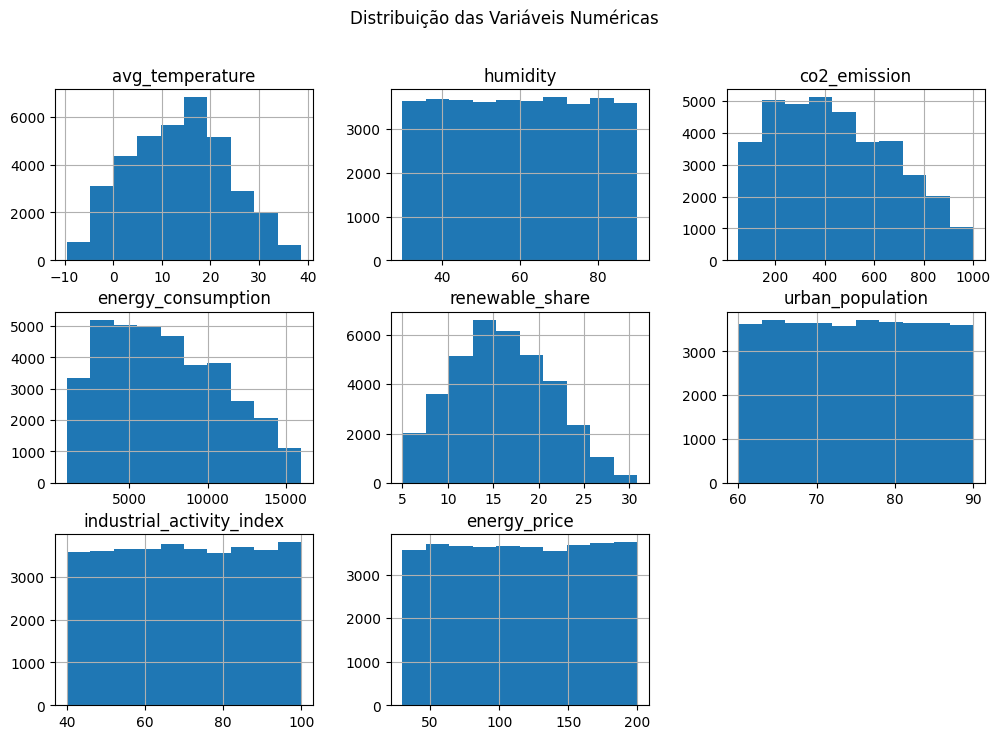

In [ ]:
# Cria histograma para mostrar a distribuição de todas as variáveis numéricas
df[num_cols].hist(figsize=(12,8))
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.show()

A análise dos histogramas mostra que o conjunto de dados apresenta características variadas. Algumas variáveis, como temperatura média e participação de energias renováveis, possuem distribuição aproximadamente normal, enquanto emissões de CO₂ e consumo de energia apresentam distribuição assimétrica, com predominância de valores mais baixos. Já as variáveis umidade, população urbana, atividade industrial e preço da energia apresentam distribuição praticamente uniforme, indicando boa cobertura dos diferentes intervalos de valores. De modo geral, não são observadas concentrações excessivas ou distribuições extremamente desequilibradas, sugerindo que o conjunto de dados possui boa variabilidade para a construção de modelos de aprendizado de máquina.


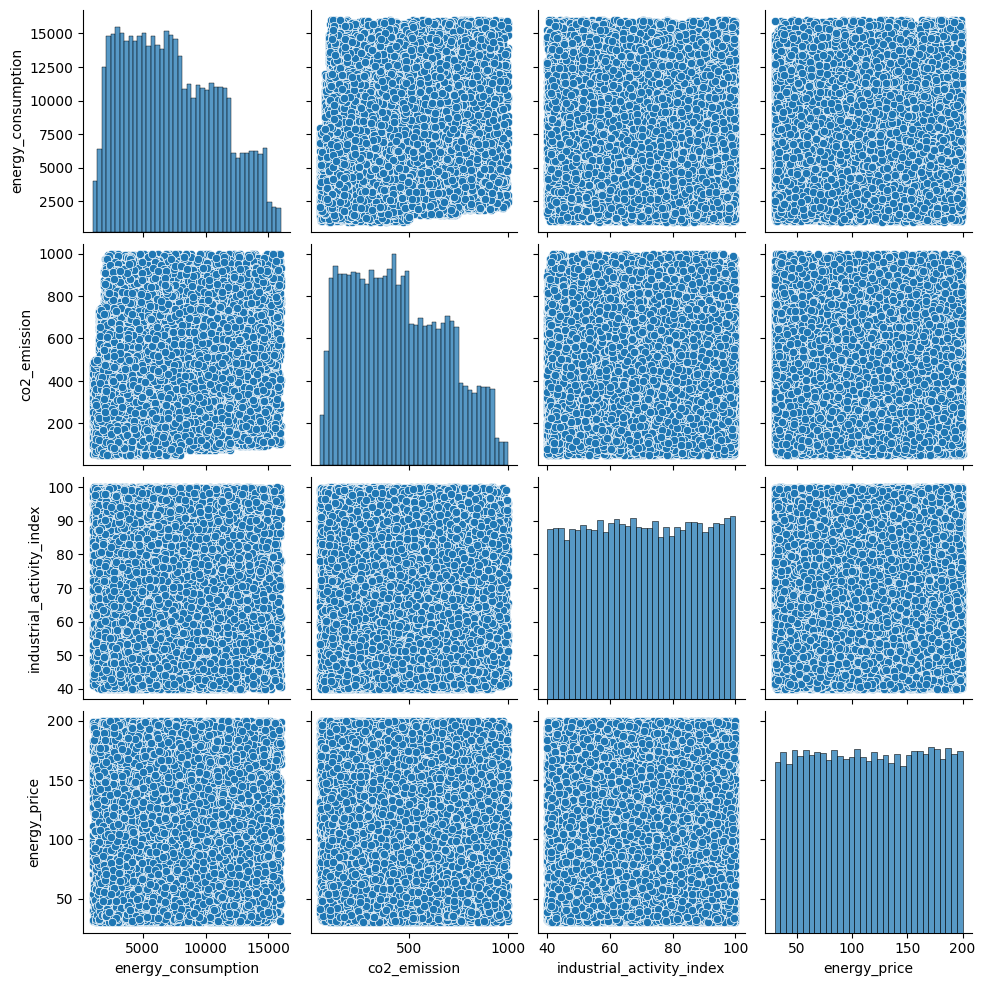

In [ ]:
#Visualizando a distribuição entre as variáveis
sns.pairplot(
    df[
        [
            'energy_consumption',
            'co2_emission',
            'industrial_activity_index',
            'energy_price'
        ]
    ]
)

A matriz de dispersão (pairplot) foi utilizada para investigar visualmente a relação entre as principais variáveis numéricas do conjunto de dados. Observa-se que os pontos encontram-se amplamente dispersos, sem formação de padrões lineares ou não lineares evidentes. Esse comportamento confirma os resultados obtidos na matriz de correlação, que indicou baixa associação entre as variáveis analisadas. Dessa forma, conclui-se que nenhuma das variáveis apresenta uma relação visualmente forte com as demais, sugerindo que um modelo de Regressão Linear poderá apresentar capacidade limitada de explicar a variabilidade da variável alvo.

In [ ]:
# Verificando Duplicidade nos dados
df.duplicated().sum()

np.int64(0)

In [ ]:
# Verificando se há "falsos nulos"
df.isin([" ", "None", "null", "N/A"]).sum()

,0
date,0
country,0
avg_temperature,0
humidity,0
co2_emission,0
energy_consumption,0
renewable_share,0
urban_population,0
industrial_activity_index,0
energy_price,0


In [ ]:
#Verificando valores nulos (missing values)
df.isnull().sum()

,0
date,0
country,0
avg_temperature,0
humidity,0
co2_emission,0
energy_consumption,0
renewable_share,0
urban_population,0
industrial_activity_index,0
energy_price,0


O Dataset utilizado não possui valores nulos e nem duplicados, descartando a necessidade de tratamento dos dados nesse quesito.

##TRATAMENTO DOS DADOS

In [ ]:
# One-Hot Encoding na variável "country"
df_model = pd.get_dummies(
    df,
    columns=['country'],
    drop_first=True
)

A variável categórica country foi transformada em variáveis binárias utilizando a técnica de One-Hot Encoding. Foi utilizado o parâmetro drop_first=True para evitar redundância entre as categorias e reduzir problemas de multicolinearidade.

In [ ]:
# Visualizando o dataset após transformação
df_model.head()

,date,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price,country_Brazil,...,country_Mexico,country_Netherlands,country_Norway,country_Poland,country_South Africa,country_Spain,country_Sweden,country_Turkey,country_United Kingdom,country_United States
0,2020-01-01,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93,False,...,False,False,False,False,False,False,False,False,False,False
1,2020-01-02,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40,False,...,False,False,False,False,False,False,False,False,False,False
2,2020-01-03,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58,False,...,False,False,False,False,False,False,False,False,False,False
3,2020-01-04,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13,False,...,False,False,False,False,False,False,False,False,False,False
4,2020-01-05,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60,False,...,False,False,False,False,False,False,False,False,False,False


## CONSTRUÇÃO DO MODELO E AVALIAÇÃO

---



In [ ]:
# Definir as variáveis independentes (X) e a variável alvo (y)
# Variável alvo
y = df_model['energy_consumption']

# Variáveis preditoras
X = df_model.drop(columns=['energy_consumption', 'date'])

A variável energy_consumption foi definida como variável alvo por representar o principal indicador de interesse do estudo. O objetivo do modelo é estimar o consumo de energia a partir de variáveis climáticas, ambientais e socioeconômicas, permitindo analisar o potencial preditivo desses fatores. Embora a análise exploratória tenha evidenciado baixa correlação linear entre a variável alvo e os atributos independentes, optou-se por manter essa escolha por sua relevância para o problema proposto e para avaliar a capacidade da Regressão Linear em modelar esse comportamento.

In [ ]:
# Divisão em Treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

O conjunto de dados foi dividido em dados de treinamento (80%) e teste (20%). O conjunto de treinamento foi utilizado para ajustar o modelo de Regressão Linear, enquanto o conjunto de teste foi reservado para avaliar sua capacidade de generalização. Foi utilizado random_state=42 para garantir a reprodutibilidade dos resultados.

In [ ]:
# Padrozizando os dados
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

As variáveis preditoras foram padronizadas utilizando o StandardScaler, que transforma os atributos para média igual a zero e desvio padrão igual a um. Essa etapa reduz o impacto das diferentes escalas das variáveis e contribui para um treinamento mais estável do modelo.

In [ ]:
# Construindo o modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Realizando as previsões
y_pred = modelo.predict(X_test)

In [ ]:
# importando as métricas
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

In [ ]:
#Calculando as métricas

# Coeficiente de determinação (R²)
r2 = r2_score(y_test, y_pred)

# Erro Absoluto Médio (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Erro Quadrático Médio (MSE)
mse = mean_squared_error(y_test, y_pred)

# Raiz do Erro Quadrático Médio (RMSE)
rmse = np.sqrt(mse)
print(f'R²: {r2:.4f}')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')

R²: 0.0300
MAE: 3082.13
MSE: 13350831.32
RMSE: 3653.88


O desempenho do modelo foi avaliado utilizando quatro métricas amplamente empregadas em problemas de regressão: o coeficiente de determinação (R²), o Erro Absoluto Médio (MAE), o Erro Quadrático Médio (MSE) e a Raiz do Erro Quadrático Médio (RMSE). O R² foi utilizado para medir a capacidade do modelo em explicar a variabilidade da variável alvo, enquanto MAE, MSE e RMSE quantificaram o erro das previsões sob diferentes perspectivas. Em conjunto, essas métricas permitem avaliar tanto a qualidade do ajuste quanto a precisão das estimativas produzidas pelo modelo.

##CONCLUSÃO


O presente projeto teve como objetivo desenvolver um modelo de Regressão Linear para prever o consumo de energia (*energy_consumption*) a partir de variáveis ambientais, econômicas e demográficas presentes no conjunto de dados.

Inicialmente, foi realizada a Análise Exploratória dos Dados, contemplando estatísticas descritivas, análise da distribuição das variáveis, matriz de correlação e gráficos de dispersão. Essas análises indicaram que as variáveis independentes apresentavam baixa correlação linear com a variável alvo, além da ausência de padrões visuais que evidenciassem uma relação linear consistente.

Após o tratamento dos dados e o treinamento do modelo de Regressão Linear, o desempenho foi avaliado por meio das métricas R², MAE, MSE e RMSE. O modelo apresentou um coeficiente de determinação (R²) de aproximadamente 0,03, indicando que apenas cerca de 3% da variação do consumo de energia foi explicada pelas variáveis utilizadas. Além disso, os valores elevados de MAE e RMSE demonstraram que as previsões apresentaram erros consideráveis em relação aos valores observados.

Os resultados obtidos confirmaram as evidências identificadas durante a etapa de análise exploratória, demonstrando que as variáveis disponíveis neste conjunto de dados não apresentam uma relação linear suficientemente forte para que a Regressão Linear produza previsões precisas do consumo de energia.

Dessa forma, conclui-se que, para este conjunto de dados, a Regressão Linear não foi capaz de representar adequadamente o comportamento da variável alvo. Como trabalhos futuros, recomenda-se investigar algoritmos capazes de modelar relações não lineares, como Árvores de Decisão, Random Forest, Gradient Boosting ou Redes Neurais, bem como explorar técnicas de engenharia de atributos que possam aumentar o poder preditivo do modelo.
